In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [18]:
materials_path = "../assets/materials/"
material_name = "broken_brick_wall"
material_textures_path = materials_path + material_name + "/textures/"
ext = ".jpg"

albedo = Image.open(material_textures_path + "albedo" + ext).convert("RGB").resize((1024, 1024))
albedo_array = np.asarray(albedo, dtype=np.float32) * (1/255.00)

block_size = 4

block_array = np.zeros((block_size, block_size, 3), dtype=np.float32)

x_offset = 135
y_offset = 440

max_x_offset = albedo_array.shape[0] - block_size
max_y_offset = albedo_array.shape[1] - block_size

x_offset = max(0, min(max_x_offset, x_offset))
y_offset = max(0, min(max_y_offset, y_offset))

for x in range(block_size):
    for y in range(block_size):
        block_array[y][x] = albedo_array[y+y_offset][x+x_offset]
        albedo_array[y+y_offset][x+x_offset] = (0.0, 1.0, 0.0)
        

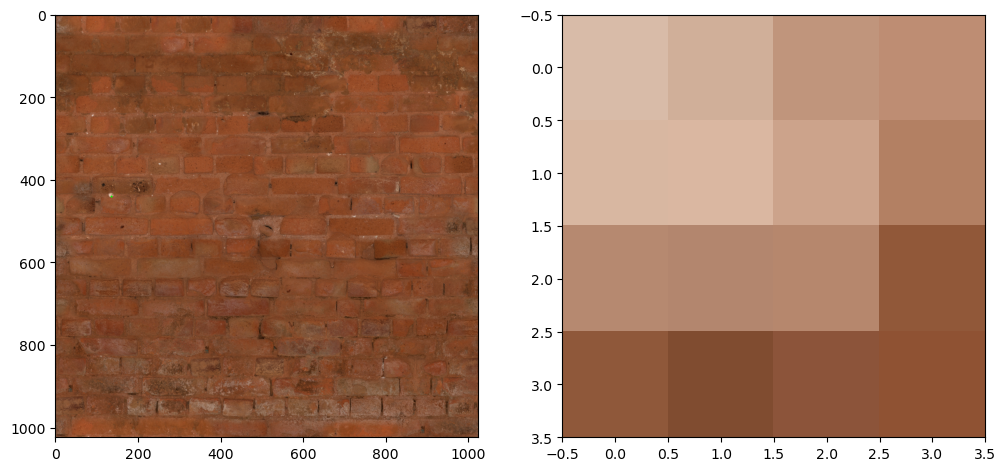

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(albedo_array)
axes[1].imshow(block_array)

plt.show()

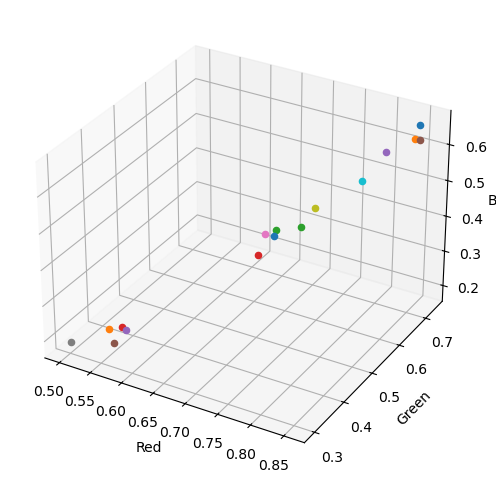

In [23]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(projection='3d')
ax.set_ybound(lower=0.0, upper=1.0)
ax.set_xbound(lower=0.0, upper=1.0)
ax.set_zbound(lower=0.0, upper=1.0)

for x in range(block_size):
    for y in range(block_size):
        ax.scatter(block_array[y][x][0], block_array[y][x][1], block_array[y][x][2])

ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')

plt.show()